In [81]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [51]:
df = pd.read_csv(r"c:\Users\jaked\Downloads\german_credit_data.csv")

In [52]:
df.shape
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


In [53]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

In [54]:
df.describe(include = "all")

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
count,1000.000000,1000.000000,1000,1000.000000,1000,817,606,1000.000000,1000.000000,1000
unique,NaN,NaN,2,NaN,3,4,3,NaN,NaN,8
top,NaN,NaN,male,NaN,own,little,little,NaN,NaN,car
freq,NaN,NaN,690,NaN,713,603,274,NaN,NaN,337
mean,499.500000,35.546000,NaN,1.904000,NaN,NaN,NaN,3271.258000,20.903000,NaN
std,288.819436,11.375469,NaN,0.653614,NaN,NaN,NaN,2822.736876,12.058814,NaN
min,0.000000,19.000000,NaN,0.000000,NaN,NaN,NaN,250.000000,4.000000,NaN
25%,249.750000,27.000000,NaN,2.000000,NaN,NaN,NaN,1365.500000,12.000000,NaN
50%,499.500000,33.000000,NaN,2.000000,NaN,NaN,NaN,2319.500000,18.000000,NaN
75%,749.250000,42.000000,NaN,2.000000,NaN,NaN,NaN,3972.250000,24.000000,NaN


In [55]:
df["Sex"].value_counts()

Sex
male      690
female    310
Name: count, dtype: int64

In [56]:
df["Sex"] = df["Sex"].replace({"male": 0, "female": 1}).astype(int)

In [57]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,0,2,own,NaN,little,1169,6,radio/TV
1,1,22,1,2,own,little,moderate,5951,48,radio/TV
2,2,49,0,1,own,little,NaN,2096,12,education
3,3,45,0,2,free,little,little,7882,42,furniture/equipment
4,4,53,0,2,free,little,little,4870,24,car


In [58]:
multi_cat_cols = ["Housing", "Saving accounts", "Checking account", "Purpose"]
df = pd.get_dummies(df, columns = multi_cat_cols, drop_first = True)

In [59]:
df.head()

,Unnamed: 0,Age,Sex,Job,Credit amount,Duration,Housing_own,Housing_rent,Saving accounts_moderate,Saving accounts_quite rich,Saving accounts_rich,Checking account_moderate,Checking account_rich,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,0,67,0,2,1169,6,True,False,False,False,False,False,False,False,False,False,False,True,False,False
1,1,22,1,2,5951,48,True,False,False,False,False,True,False,False,False,False,False,True,False,False
2,2,49,0,1,2096,12,True,False,False,False,False,False,False,False,False,True,False,False,False,False
3,3,45,0,2,7882,42,False,False,False,False,False,False,False,False,False,False,True,False,False,False
4,4,53,0,2,4870,24,False,False,False,False,False,False,False,True,False,False,False,False,False,False


In [64]:
df = df.drop("Unnamed: 0", axis = 1)

In [70]:
df["Risk"] = pd.cut(df["Credit amount"], 
                    bins = [-float("inf"),
                            df["Credit amount"].quantile(0.33),
                            df["Credit amount"].quantile(0.66),
                            float("inf")], 
                    labels = ["Low", "Medium", "High"])

In [74]:
df.head()

,Age,Sex,Job,Credit amount,Duration,Housing_own,Housing_rent,Saving accounts_moderate,Saving accounts_quite rich,Saving accounts_rich,Checking account_moderate,Checking account_rich,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others,Risk
0,67,0,2,1169,6,1,0,0,0,0,0,0,0,0,0,0,1,0,0,Low
1,22,1,2,5951,48,1,0,0,0,0,1,0,0,0,0,0,1,0,0,High
2,49,0,1,2096,12,1,0,0,0,0,0,0,0,0,1,0,0,0,0,Medium
3,45,0,2,7882,42,0,0,0,0,0,0,0,0,0,0,1,0,0,0,High
4,53,0,2,4870,24,0,0,0,0,0,0,0,1,0,0,0,0,0,0,High


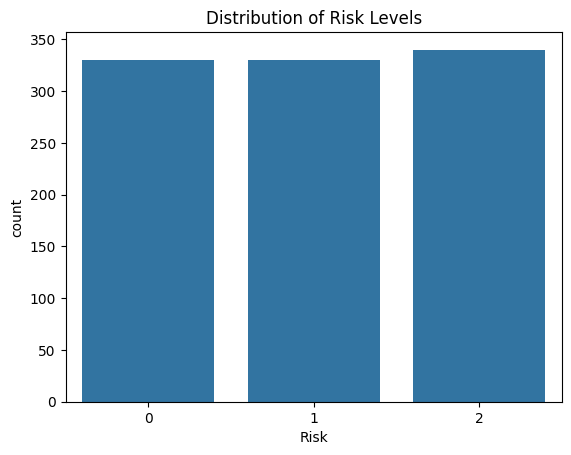

In [87]:
sns.countplot(x='Risk', data=df)
plt.title('Distribution of Risk Levels')
plt.show()

In [71]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   Age                          1000 non-null   int64   
 1   Sex                          1000 non-null   int64   
 2   Job                          1000 non-null   int64   
 3   Credit amount                1000 non-null   int64   
 4   Duration                     1000 non-null   int64   
 5   Housing_own                  1000 non-null   int64   
 6   Housing_rent                 1000 non-null   int64   
 7   Saving accounts_moderate     1000 non-null   int64   
 8   Saving accounts_quite rich   1000 non-null   int64   
 9   Saving accounts_rich         1000 non-null   int64   
 10  Checking account_moderate    1000 non-null   int64   
 11  Checking account_rich        1000 non-null   int64   
 12  Purpose_car                  1000 non-null   int64   
 13  Purpose_domesti

In [72]:
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

In [73]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   Age                          1000 non-null   int64   
 1   Sex                          1000 non-null   int64   
 2   Job                          1000 non-null   int64   
 3   Credit amount                1000 non-null   int64   
 4   Duration                     1000 non-null   int64   
 5   Housing_own                  1000 non-null   int64   
 6   Housing_rent                 1000 non-null   int64   
 7   Saving accounts_moderate     1000 non-null   int64   
 8   Saving accounts_quite rich   1000 non-null   int64   
 9   Saving accounts_rich         1000 non-null   int64   
 10  Checking account_moderate    1000 non-null   int64   
 11  Checking account_rich        1000 non-null   int64   
 12  Purpose_car                  1000 non-null   int64   
 13  Purpose_domesti

In [88]:
print(df.isnull().sum())

Age                            0
Sex                            0
Job                            0
Credit amount                  0
Duration                       0
Housing_own                    0
Housing_rent                   0
Saving accounts_moderate       0
Saving accounts_quite rich     0
Saving accounts_rich           0
Checking account_moderate      0
Checking account_rich          0
Purpose_car                    0
Purpose_domestic appliances    0
Purpose_education              0
Purpose_furniture/equipment    0
Purpose_radio/TV               0
Purpose_repairs                0
Purpose_vacation/others        0
Risk                           0
dtype: int64


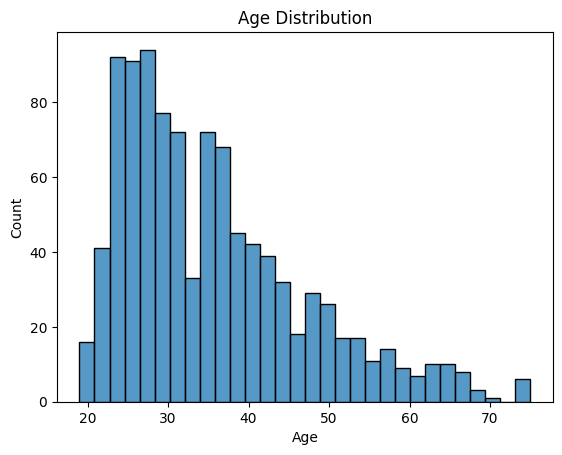

In [90]:
sns.histplot(df['Age'], bins=30)
plt.title('Age Distribution')
plt.show()

In [69]:
print(df.columns.tolist())
print(df.head())

['Age', 'Sex', 'Job', 'Credit amount', 'Duration', 'Housing_own', 'Housing_rent', 'Saving accounts_moderate', 'Saving accounts_quite rich', 'Saving accounts_rich', 'Checking account_moderate', 'Checking account_rich', 'Purpose_car', 'Purpose_domestic appliances', 'Purpose_education', 'Purpose_furniture/equipment', 'Purpose_radio/TV', 'Purpose_repairs', 'Purpose_vacation/others']
   Age  Sex  Job  Credit amount  Duration  Housing_own  Housing_rent  \
0   67    0    2           1169         6            1             0   
1   22    1    2           5951        48            1             0   
2   49    0    1           2096        12            1             0   
3   45    0    2           7882        42            0             0   
4   53    0    2           4870        24            0             0   

   Saving accounts_moderate  Saving accounts_quite rich  Saving accounts_rich  \
0                         0                           0                     0   
1                      

In [84]:
df['Risk'] = df['Risk'].map({'Low': 0, 'Medium': 1, 'High': 2})

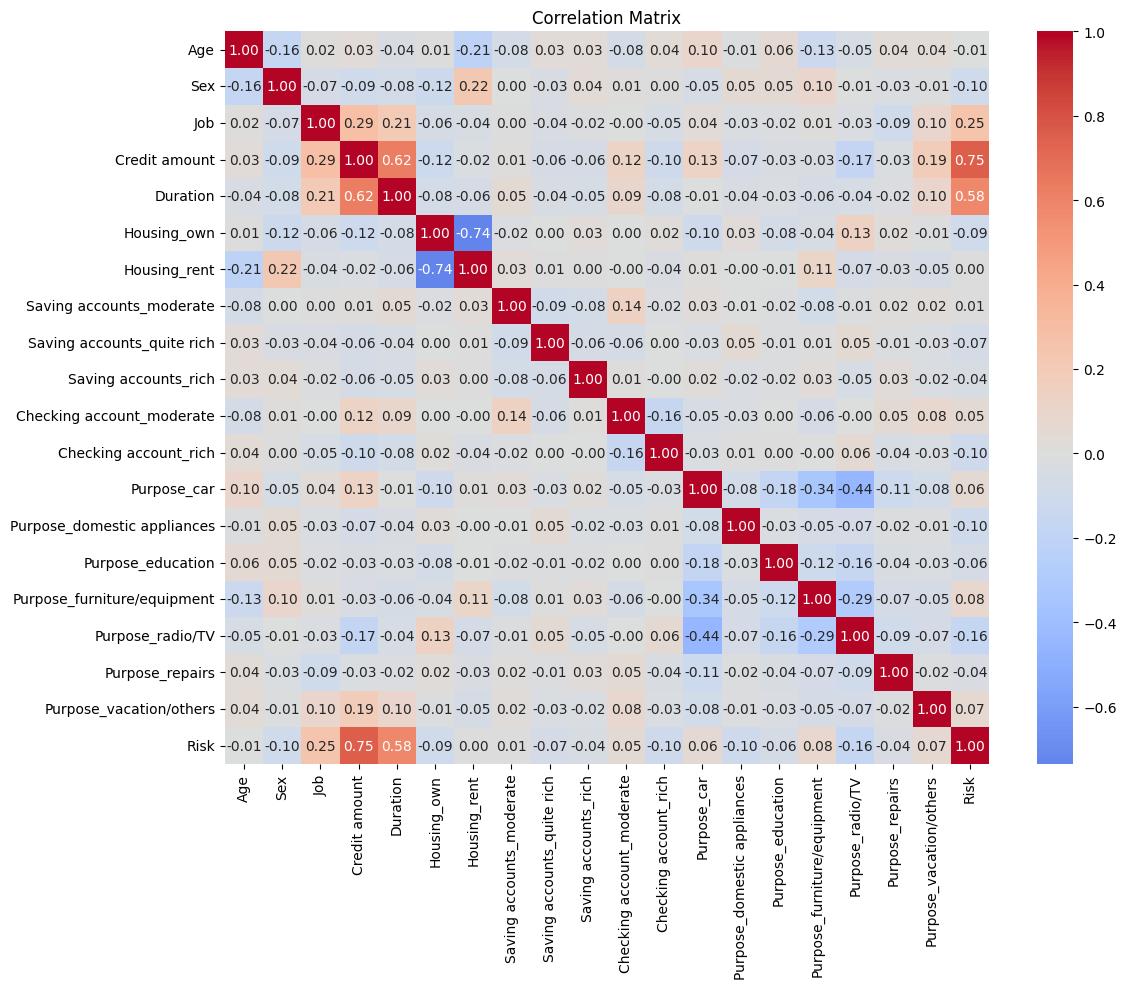

In [85]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

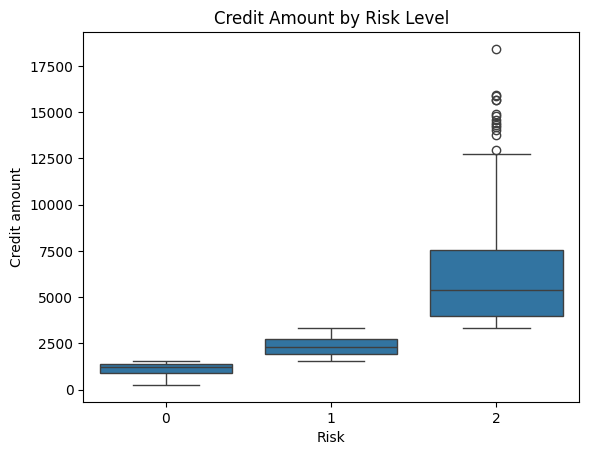

In [89]:
# Example for Credit amount
sns.boxplot(x='Risk', y='Credit amount', data=df)
plt.title('Credit Amount by Risk Level')
plt.show()